## Polynomial Regression and the Degree Hyperparameter

### The Theory: The Feature Engineering Trick

The biggest secret of Polynomial Regression is that it is not a new algorithm. It is literally just Multiple Linear Regression in disguise.

If your data curves, a standard linear equation ($y = b_0 + b_1x$) cannot bend to fit it. To force the line to bend, we mathematically engineer new features out of our existing data by raising them to a power.

We transform our single $x$ into $x^2, x^3, \dots, x^n$.

The new equation becomes:

$$y = b_0 + b_1x + b_2x^2 + b_3x^3 + \dots + b_nx^n$$

Because the coefficients ($b_1, b_2$) are still linear, the Scikit-Learn `LinearRegression` engine can solve this exactly like it did before. The algorithm thinks it is drawing a flat plane in a multi-dimensional room, but when we project that back down to our standard 2D graph, it looks like a curving line.

### The Hyperparameter: Degree ($n$)

The "Degree" dictates how many times you square or cube your features.

*   **Degree 1:** $y = b_0 + b_1x$ (A straight line).
*   **Degree 2:** $y = b_0 + b_1x + b_2x^2$ (A U-shaped parabola).
*   **Degree 3:** $y = b_0 + b_1x + b_2x^2 + b_3x^3$ (An S-curve).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

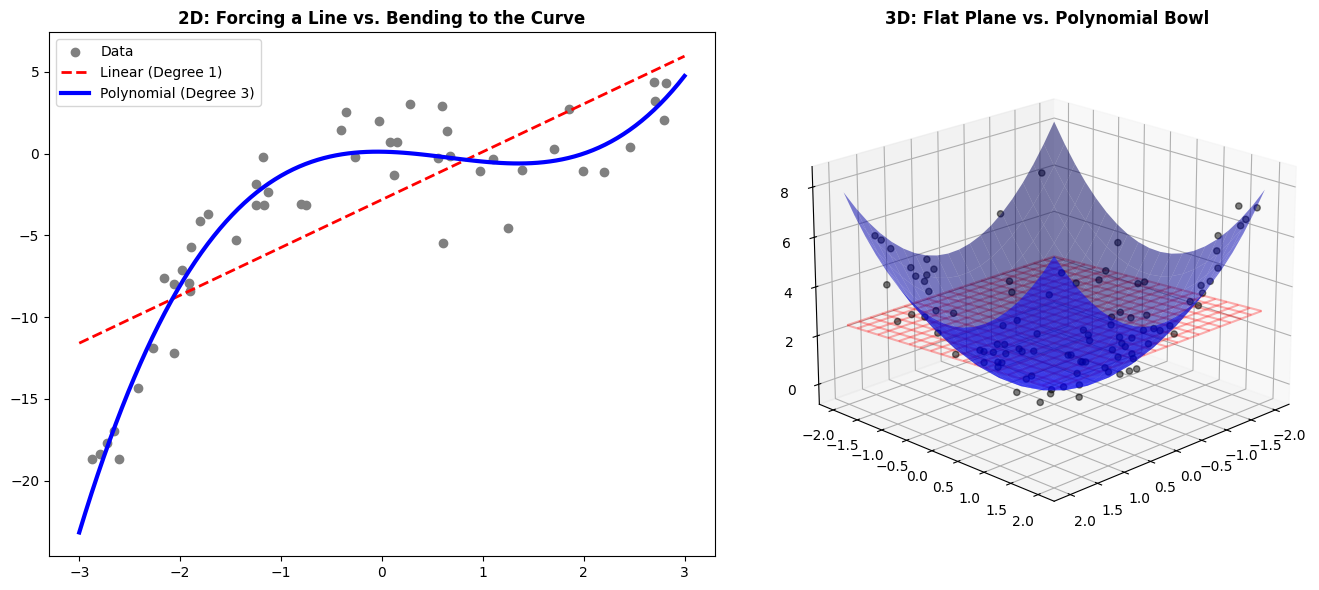

In [5]:
# Define the polynomial degrees to experiment with
degree_2d = 3  # Change this to 1, 2, 3, etc., to see different curves
degree_3d = 2  # Change this to 1, 2, 3, etc., to see different surfaces

# --- The 2-D comparison (curve vs. line) ---
np.random.seed(42)
X_2d = np.sort(np.random.uniform(-3, 3, 50)).reshape(-1, 1)
# Create curved data (y = 0.5 * x^3 - x^2 + noise)
y_2d = 0.5 * X_2d[:, 0]**3 - X_2d[:, 0]**2 + np.random.normal(0, 2, 50)

# Train Degree 1 (Linear)
lin_reg = LinearRegression()
lin_reg.fit(X_2d, y_2d)

# Train Polynomial model with configurable degree
poly_model = make_pipeline(PolynomialFeatures(degree=degree_2d), LinearRegression())
poly_model.fit(X_2d, y_2d)

# Generate smooth line for plotting
X_plot = np.linspace(-3, 3, 100).reshape(-1, 1)

# Create a single figure for both 2D and 3D plots
fig = plt.figure(figsize=(14, 6))

# Plot 2D
ax1 = fig.add_subplot(121)
ax1.scatter(X_2d, y_2d, color='gray', label='Data')
ax1.plot(X_plot, lin_reg.predict(X_plot), color='red', linestyle='--', linewidth=2, label='Linear (Degree 1)')
ax1.plot(X_plot, poly_model.predict(X_plot), color='blue', linewidth=3, label=f'Polynomial (Degree {degree_2d})')
ax1.set_title('2D: Forcing a Line vs. Bending to the Curve', fontweight='bold')
ax1.legend()

# --- The 3-D comparison ---
# Create two features
X1 = np.random.uniform(-2, 2, 100)
X2 = np.random.uniform(-2, 2, 100)
X_3d = np.c_[X1, X2]
# Create a bowl-shaped target
y_3d = X1**2 + X2**2 + np.random.normal(0, 0.5, 100)

# Train Degree 1 (Flat Plane)
lin_reg_3d = LinearRegression()
lin_reg_3d.fit(X_3d, y_3d)

# Train Polynomial model with configurable degree
poly_3d = make_pipeline(PolynomialFeatures(degree=degree_3d), LinearRegression())
poly_3d.fit(X_3d, y_3d)

# Create meshgrid for 3D plotting
x1_mesh, x2_mesh = np.meshgrid(np.linspace(-2, 2, 20), np.linspace(-2, 2, 20))
X_mesh_flat = np.c_[x1_mesh.ravel(), x2_mesh.ravel()]

# Predict surfaces
Z_lin = lin_reg_3d.predict(X_mesh_flat).reshape(x1_mesh.shape)
Z_poly = poly_3d.predict(X_mesh_flat).reshape(x1_mesh.shape)

# Plot 3D on the same figure
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X1, X2, y_3d, color='black', label='Data points', alpha=0.5)

# Plot Flat Plane (Red, wireframe so we can see through it)
ax2.plot_wireframe(x1_mesh, x2_mesh, Z_lin, color='red', alpha=0.3, label='Linear Plane')

# Plot Curved Surface (Blue, solid) with configurable degree
ax2.plot_surface(x1_mesh, x2_mesh, Z_poly, color='blue', alpha=0.5, label=f'Polynomial (Degree {degree_3d})')

ax2.set_title('3D: Flat Plane vs. Polynomial Bowl', fontweight='bold')
ax2.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()